Dataset Summary:
          footfall    tempMode          AQ         USS          CS  \
count   944.000000  944.000000  944.000000  944.000000  944.000000   
mean    306.381356    3.727754    4.325212    2.939619    5.394068   
std    1082.606745    2.677235    1.438436    1.383725    1.269349   
min       0.000000    0.000000    1.000000    1.000000    1.000000   
25%       1.000000    1.000000    3.000000    2.000000    5.000000   
50%      22.000000    3.000000    4.000000    3.000000    6.000000   
75%     110.000000    7.000000    6.000000    4.000000    6.000000   
max    7300.000000    7.000000    7.000000    7.000000    7.000000   

              VOC          RP          IP  Temperature        fail  
count  944.000000  944.000000  944.000000   944.000000  944.000000  
mean     2.842161   47.043432    4.565678    16.331568    0.416314  
std      2.273337   16.423130    1.599287     5.974781    0.493208  
min      0.000000   19.000000    1.000000     1.000000    0.000000  
25%    

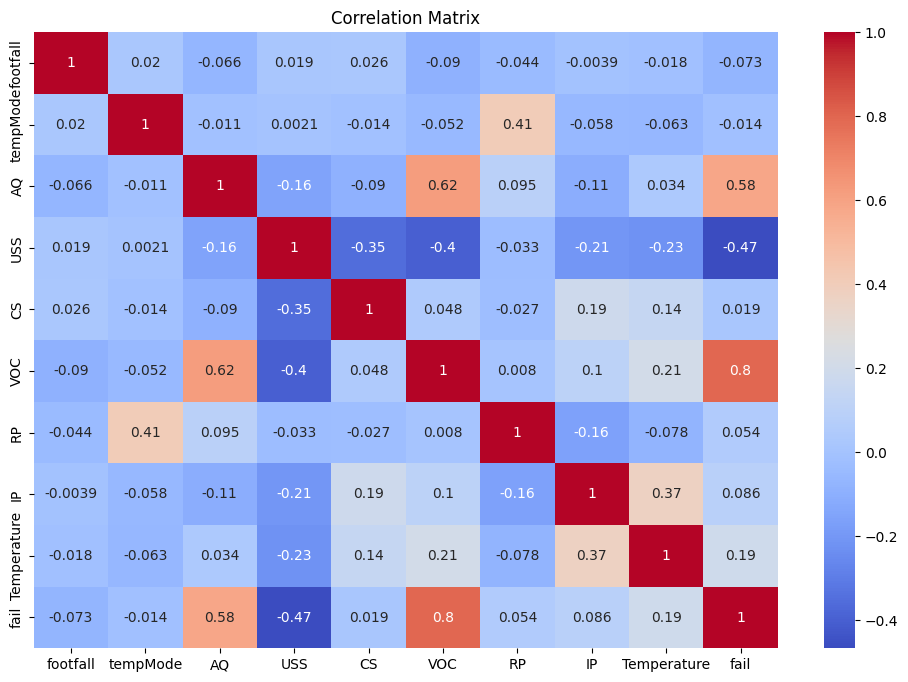

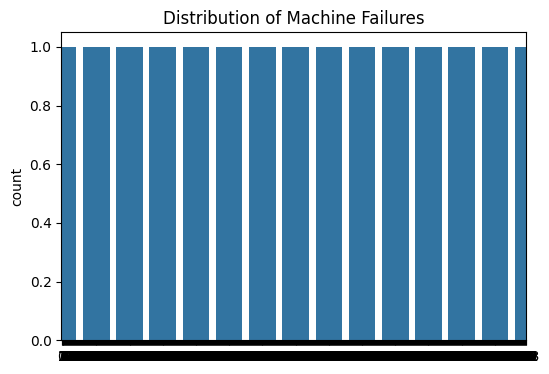


Model: RandomForest
Accuracy: 0.8889, ROC AUC: 0.9552
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.90      0.90       102
           1       0.88      0.87      0.88        87

    accuracy                           0.89       189
   macro avg       0.89      0.89      0.89       189
weighted avg       0.89      0.89      0.89       189

Confusion Matrix:
 [[92 10]
 [11 76]]

Model: LogisticRegression
Accuracy: 0.8783, ROC AUC: 0.9477
Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.87      0.89       102
           1       0.86      0.89      0.87        87

    accuracy                           0.88       189
   macro avg       0.88      0.88      0.88       189
weighted avg       0.88      0.88      0.88       189

Confusion Matrix:
 [[89 13]
 [10 77]]

Model: SVM
Accuracy: 0.8677, ROC AUC: 0.9562
Classification Report:
               precision    recall  f

  File "c:\Users\HP\AppData\Local\Programs\Python\Python38\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\HP\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 489, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\HP\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 854, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\HP\AppData\Local\Programs\Python\Python38\lib\subprocess.py", line 1307, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



Model: KNN
Accuracy: 0.8571, ROC AUC: 0.9225
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.87      0.87       102
           1       0.85      0.84      0.84        87

    accuracy                           0.86       189
   macro avg       0.86      0.86      0.86       189
weighted avg       0.86      0.86      0.86       189

Confusion Matrix:
 [[89 13]
 [14 73]]

Model: XGBoost
Accuracy: 0.8624, ROC AUC: 0.9274
Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87       102
           1       0.85      0.85      0.85        87

    accuracy                           0.86       189
   macro avg       0.86      0.86      0.86       189
weighted avg       0.86      0.86      0.86       189

Confusion Matrix:
 [[89 13]
 [13 74]]

Voting Classifier
Accuracy: 0.8677, ROC AUC: 0.9555
Confusion Matrix:
 [[90 12]
 [13 74]]


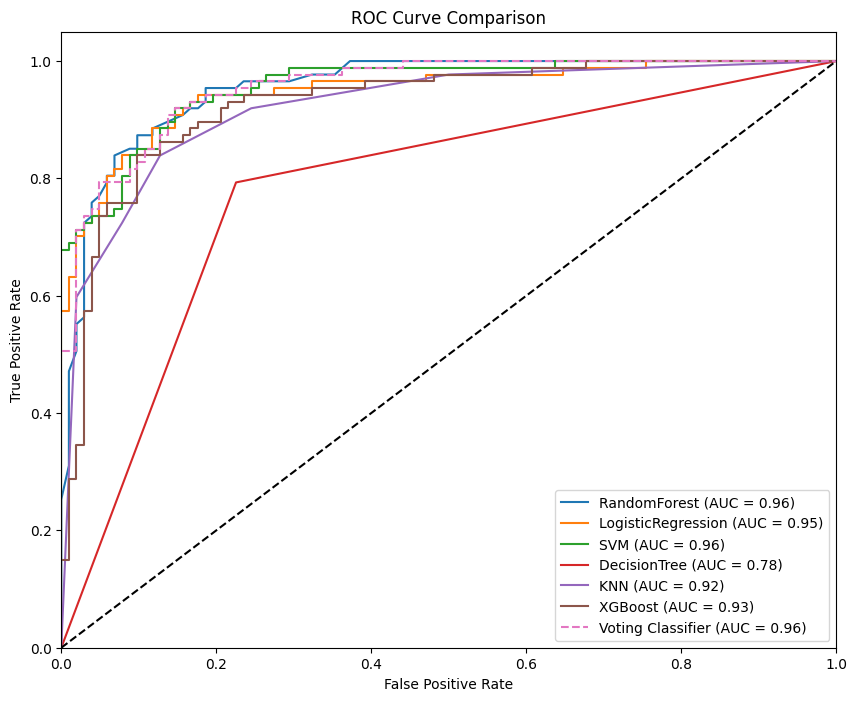

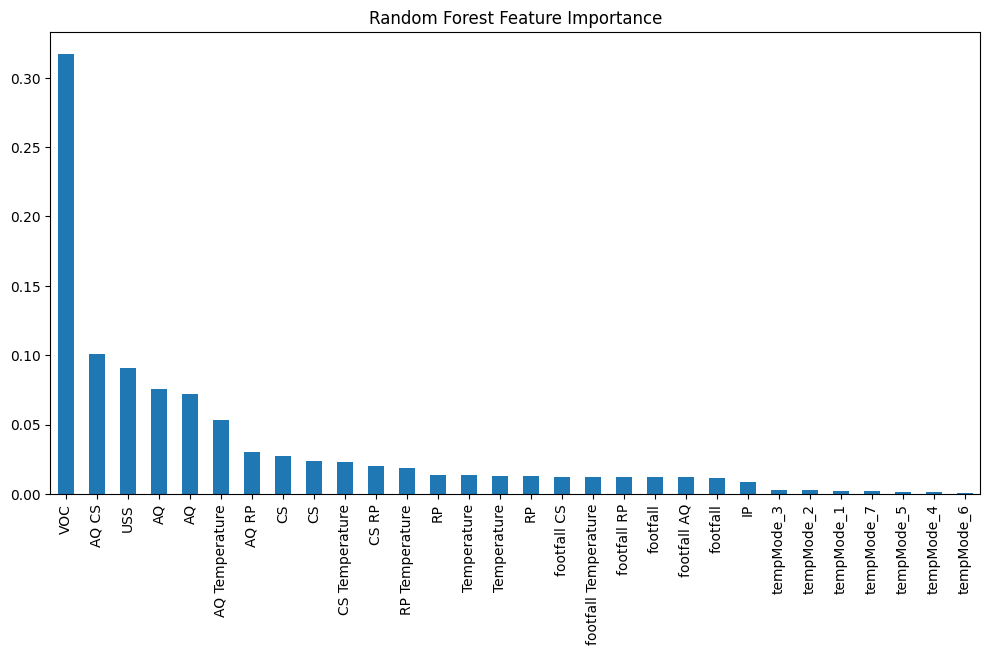

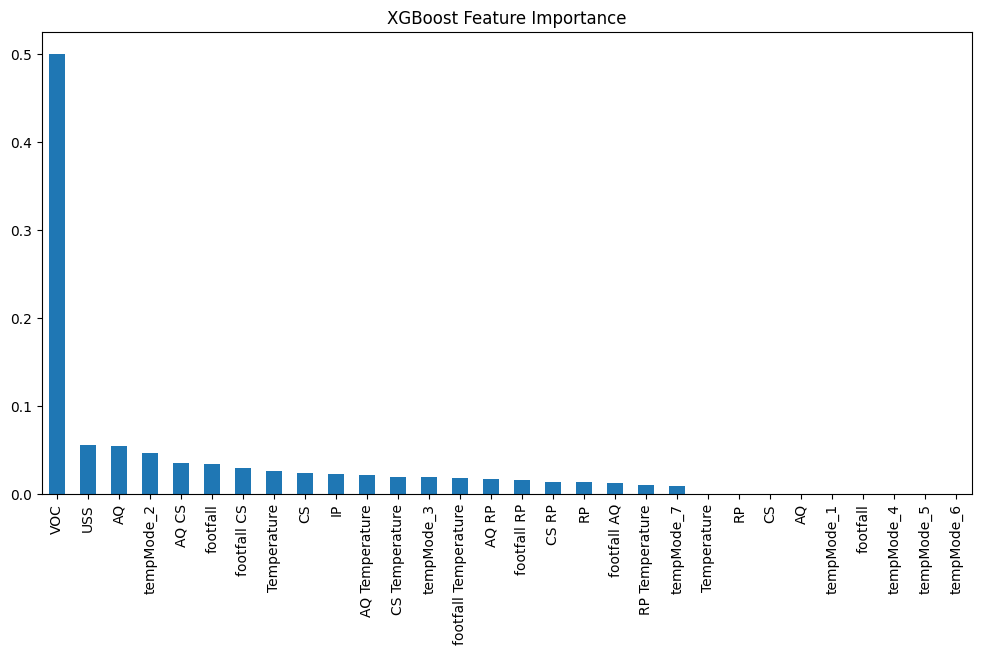

RandomForest - Mean CV Accuracy: 0.9179 ± 0.0190
LogisticRegression - Mean CV Accuracy: 0.9113 ± 0.0130
SVM - Mean CV Accuracy: 0.9073 ± 0.0042
DecisionTree - Mean CV Accuracy: 0.8503 ± 0.0267
KNN - Mean CV Accuracy: 0.8609 ± 0.0248
XGBoost - Mean CV Accuracy: 0.9166 ± 0.0136

Final Results Summary:
                    Accuracy   ROC AUC
RandomForest        0.888889  0.955206
LogisticRegression  0.878307  0.947712
SVM                 0.867725  0.956164
DecisionTree        0.783069  0.783807
KNN                 0.857143  0.922470
XGBoost             0.862434  0.927428
VotingClassifier    0.867725  0.955488


In [1]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')

# Step 2: Load dataset
data = pd.read_csv(r'C:\Users\HP\Downloads\Data Science Machine failure prediction - Major project\Machine failure prediction - Major project\data (1).csv')

# Step 3: Data Exploration (EDA)
print("Dataset Summary:")
print(data.describe())
print("\nMissing Values:\n", data.isnull().sum())

# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

# Distribution of the target variable
plt.figure(figsize=(6,4))
sns.countplot(data['fail'])
plt.title('Distribution of Machine Failures')
plt.show()

# Step 4: Feature Engineering (Interaction terms, polynomial features)
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
poly_features = poly.fit_transform(data[['footfall', 'AQ', 'CS', 'RP', 'Temperature']])
poly_df = pd.DataFrame(poly_features, columns=poly.get_feature_names_out(['footfall', 'AQ', 'CS', 'RP', 'Temperature']))

# Add polynomial features to the original dataset
data = pd.concat([data, poly_df], axis=1)

# One-hot encode 'tempMode'
data = pd.get_dummies(data, columns=['tempMode'], drop_first=True)

# Step 5: Feature Scaling
X = data.drop('fail', axis=1)  # Features
y = data['fail']               # Target

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 6: Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Step 7: Initialize various models
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'LogisticRegression': LogisticRegression(random_state=42),
    'SVM': SVC(random_state=42, probability=True),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42)
}

# Step 8: Hyperparameter Tuning (for RandomForest)
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}
rf_grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=5, n_jobs=-1)
rf_grid_search.fit(X_train, y_train)
best_rf = rf_grid_search.best_estimator_

# Step 9: Model Training and Evaluation
results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    results[model_name] = {'Accuracy': acc, 'ROC AUC': roc_auc}
    print(f"\nModel: {model_name}")
    print(f"Accuracy: {acc:.4f}, ROC AUC: {roc_auc:.4f}")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Step 10: Voting Classifier (Ensemble of the best models)
voting_clf = VotingClassifier(estimators=[
    ('RandomForest', best_rf),
    ('XGBoost', models['XGBoost']),
    ('SVM', models['SVM'])
], voting='soft')
voting_clf.fit(X_train, y_train)
y_pred_voting = voting_clf.predict(X_test)
voting_acc = accuracy_score(y_test, y_pred_voting)
voting_roc_auc = roc_auc_score(y_test, voting_clf.predict_proba(X_test)[:, 1])
results['VotingClassifier'] = {'Accuracy': voting_acc, 'ROC AUC': voting_roc_auc}
print("\nVoting Classifier")
print(f"Accuracy: {voting_acc:.4f}, ROC AUC: {voting_roc_auc:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_voting))

# Step 11: Plotting ROC Curves
plt.figure(figsize=(10,8))
for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.2f})")
fpr, tpr, _ = roc_curve(y_test, voting_clf.predict_proba(X_test)[:,1])
plt.plot(fpr, tpr, label=f"Voting Classifier (AUC = {voting_roc_auc:.2f})", linestyle='--')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.show()

# Step 12: Feature Importance (for Random Forest and XGBoost)
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
xgb_importances = pd.Series(models['XGBoost'].feature_importances_, index=X.columns)

# Plotting Feature Importances
plt.figure(figsize=(12, 6))
rf_importances.sort_values(ascending=False).plot(kind='bar', title='Random Forest Feature Importance')
plt.show()

plt.figure(figsize=(12, 6))
xgb_importances.sort_values(ascending=False).plot(kind='bar', title='XGBoost Feature Importance')
plt.show()

# Step 13: Cross-Validation for Model Comparison
kf = StratifiedKFold(n_splits=5)
cv_results = {}
for model_name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
    cv_results[model_name] = {'Mean Accuracy': scores.mean(), 'Std Dev': scores.std()}
    print(f"{model_name} - Mean CV Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

# Step 14: Results Summary
results_df = pd.DataFrame(results).T
print("\nFinal Results Summary:")
print(results_df)

